In [ ]:
# analyze the skew of each feature
# investigate what taking the monthly mean and median of each feature across counties does to each feature
# create the monthly aggregated dataset
# investigate the PACF ACF and stationarity of different transformations on the rate variable

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')

In [ ]:
import utils

In [ ]:
aggregate_all_counties_df = pd.read_csv('/content/drive/MyDrive/DSSI/Project/Valley Fever - Environmental/data_processed/aggregate/aggregate_all_counties_2001_2024.csv', parse_dates=['Year-Month'])
aggregate_all_counties_df

,County,Year-Month,Precipitation,Avg Rel Hum (%),Avg Wind Speed (mph),Wind Run (miles),windeventcount,Avg Soil Temp (F),AQI_PM25,AQI_PM10,FIRE_Acres_Burned,fungicide_lbs_prd_used,rodent_lbs_prd_used,rate_per_100k
0,Fresno,2001-01-01,1.650000,80.668817,4.135090,3055.316667,0.500000,47.968487,114.5,58.0,NaN,18077.0509,36543.6300,0.368994
1,Fresno,2001-02-01,1.405000,77.186949,5.010119,3367.650000,1.166667,50.158929,86.0,20.0,NaN,42439.2841,45532.6519,0.000000
2,Fresno,2001-03-01,1.120000,71.832258,4.940860,3676.616667,0.833333,57.800323,68.0,40.0,NaN,138455.3561,67811.0935,0.000000
3,Fresno,2001-04-01,0.670000,60.152020,5.575386,3880.950000,0.333333,60.411010,52.5,31.5,NaN,92001.9361,29471.3377,0.122998
4,Fresno,2001-05-01,0.443333,38.955556,6.362903,4735.700000,1.500000,70.422975,56.5,47.0,NaN,111242.7386,90223.1172,0.122998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2299,Ventura,2024-08-01,1.850000,71.903226,3.314516,2465.350000,0.000000,73.524194,49.0,25.0,1459.0,NaN,NaN,2.655587
2300,Ventura,2024-09-01,1.355000,74.871839,3.211667,2316.400000,0.000000,71.306667,47.5,23.0,74536.0,NaN,NaN,2.655587
2301,Ventura,2024-10-01,0.810000,70.774194,3.035484,2259.250000,0.000000,67.398387,47.0,26.0,424.0,NaN,NaN,3.621255
2302,Ventura,2024-11-01,0.725000,53.566667,3.706667,2666.250000,0.500000,58.956667,31.0,22.5,529.0,NaN,NaN,5.431883


In [ ]:
variables = [
    "Precipitation",
    "Avg Rel Hum (%)",
    "Avg Wind Speed (mph)",
    "Wind Run (miles)",
    "windeventcount",
    "Avg Soil Temp (F)",
    "AQI_PM25",
    "AQI_PM10",
    "FIRE_Acres_Burned",
    "fungicide_lbs_prd_used",
    "rodent_lbs_prd_used",
    "rate_per_100k"
]

In [ ]:
# plotting the distribution of all values for each variable

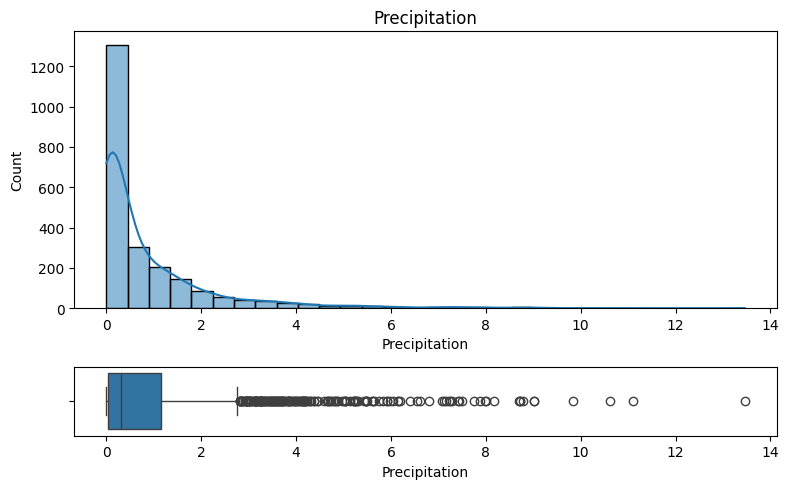

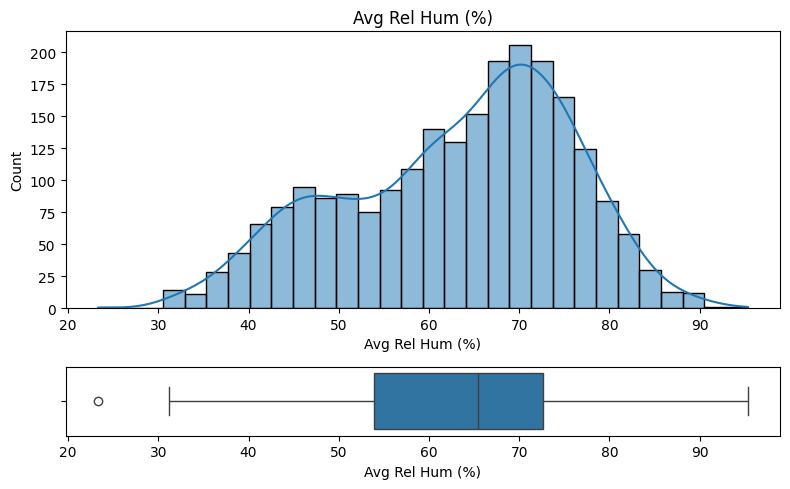

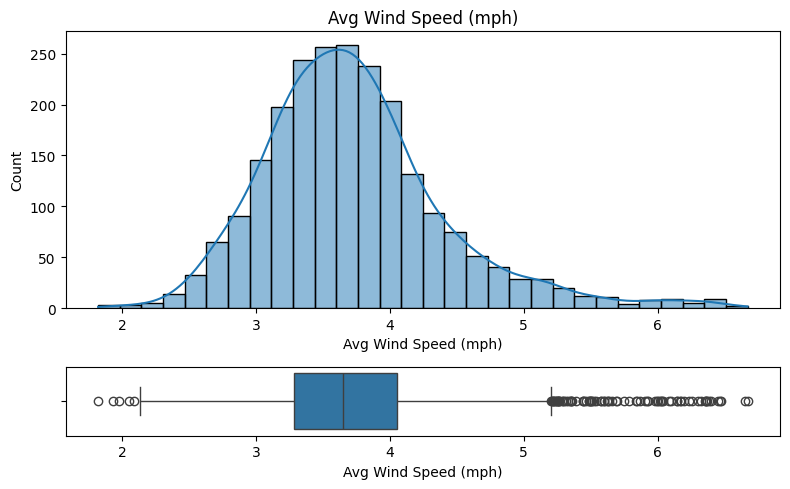

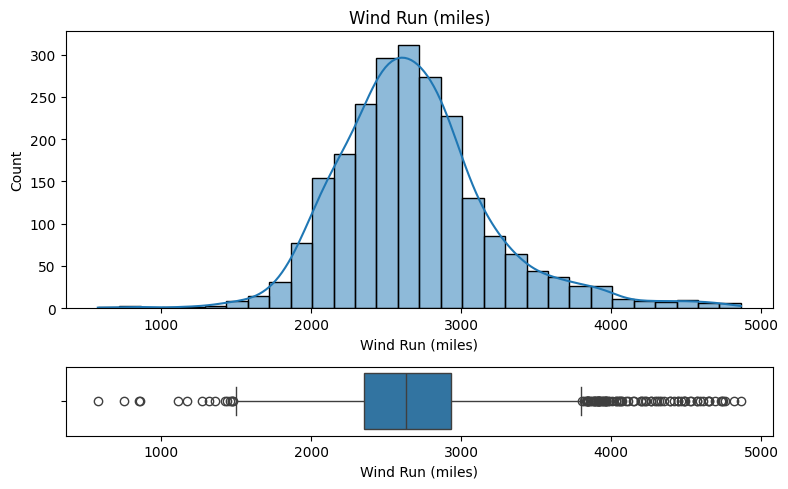

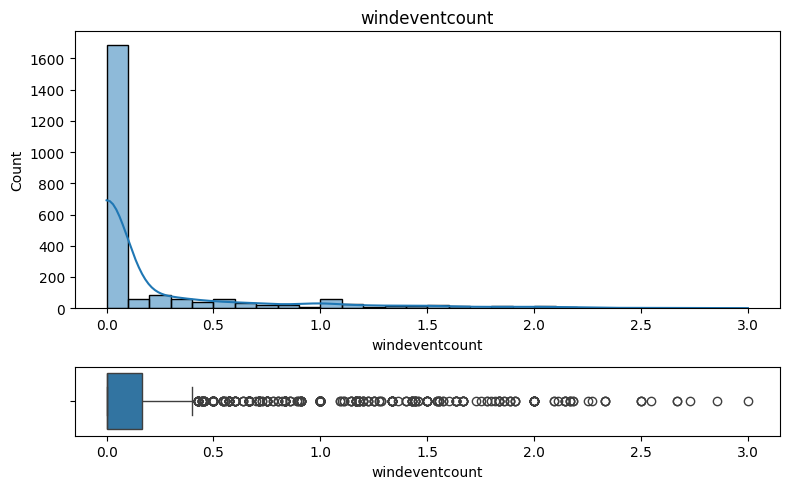

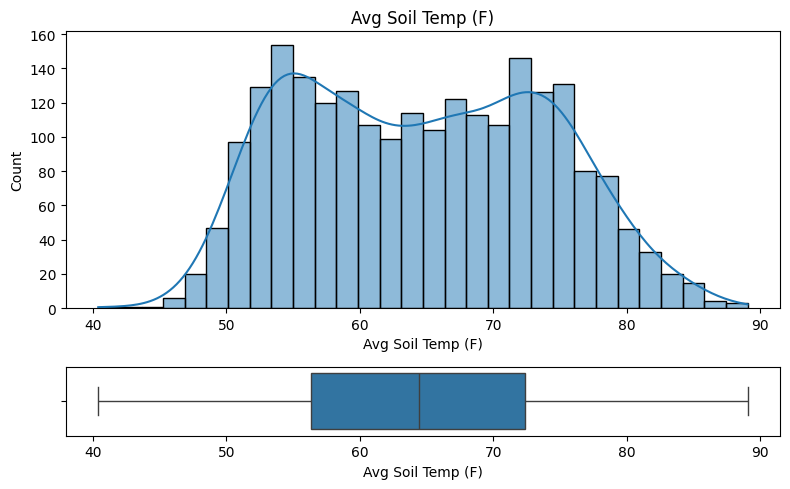

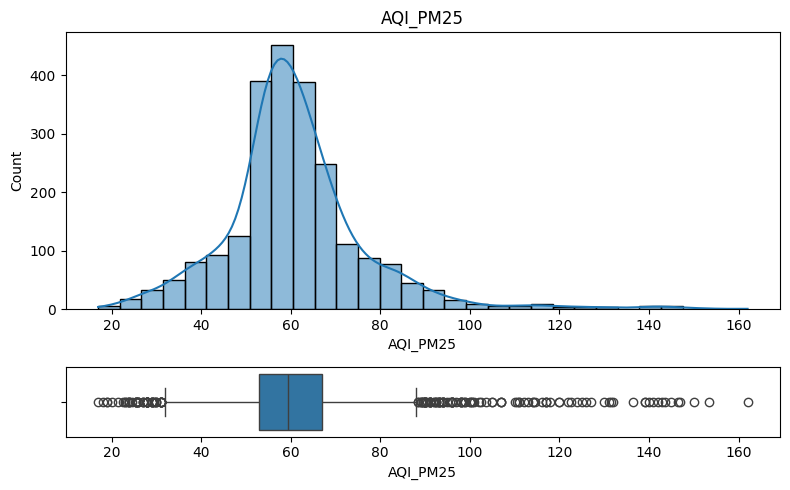

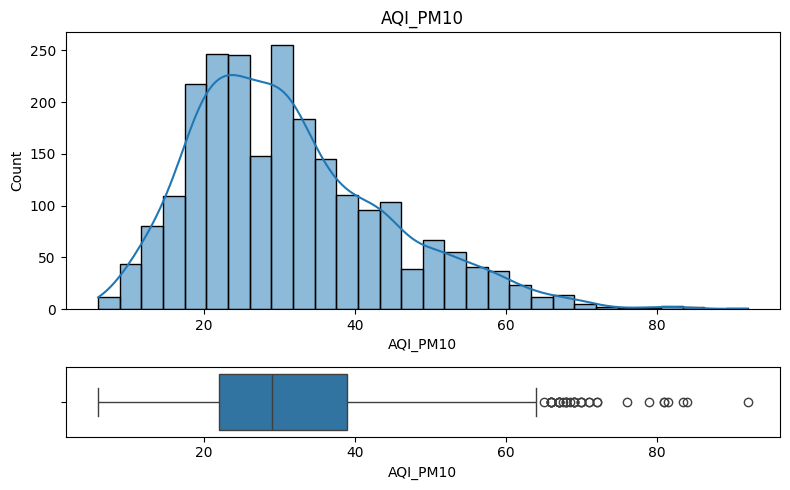

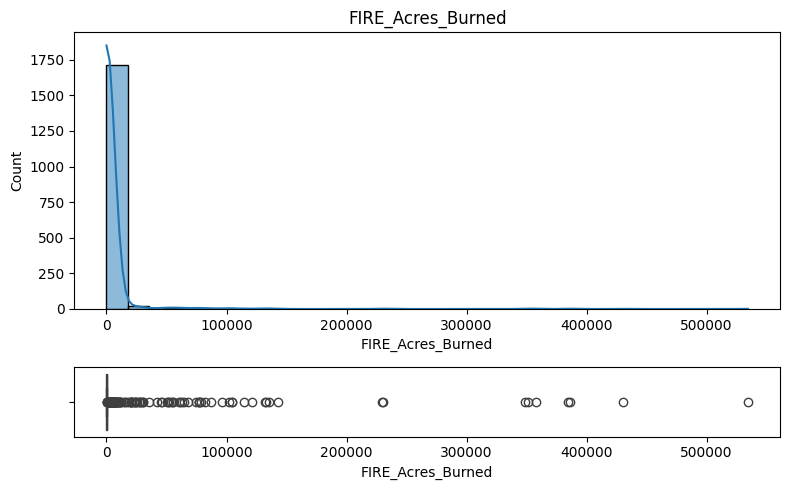

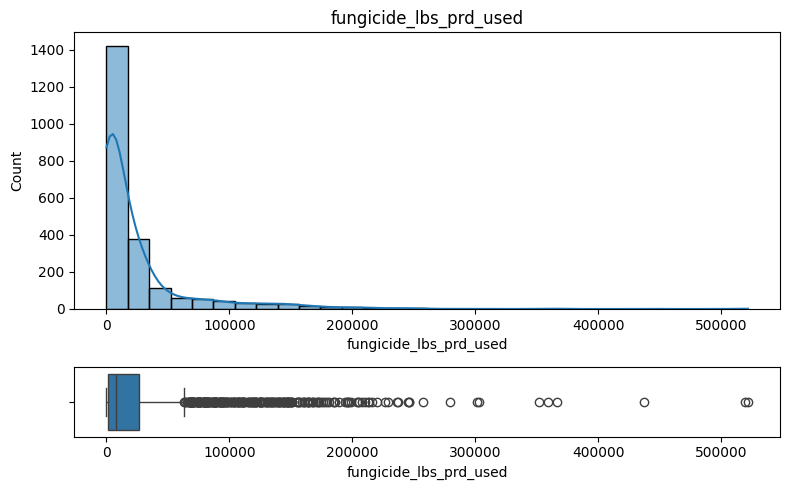

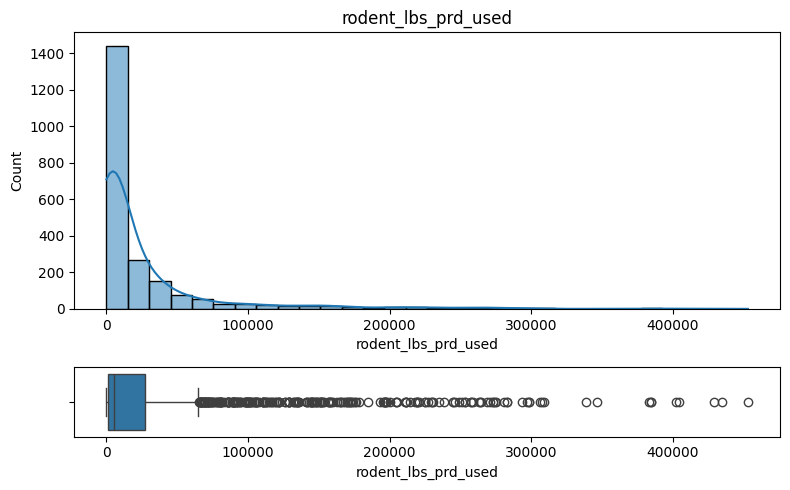

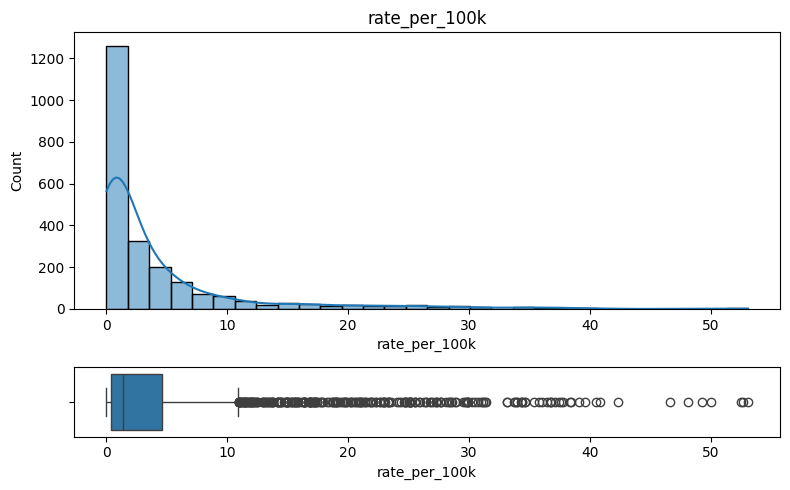

In [ ]:
import seaborn as sns

for var in variables:
    fig, axes = plt.subplots(
        2,1,
        figsize=(8,5),
        gridspec_kw={'height_ratios':[4,1]}
    )

    sns.histplot(aggregate_all_counties_df[var], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(var)

    sns.boxplot(x=aggregate_all_counties_df[var], ax=axes[1])

    plt.tight_layout()
    plt.show()

In [ ]:
# understanding the skewness of each variable

In [ ]:
for var in variables:
    print(f"{var}: {aggregate_all_counties_df[var].skew():.2f}")

Precipitation: 3.07
Avg Rel Hum (%): -0.41
Avg Wind Speed (mph): 0.97
Wind Run (miles): 0.78
windeventcount: 2.71
Avg Soil Temp (F): 0.12
AQI_PM25: 1.39
AQI_PM10: 0.85
FIRE_Acres_Burned: 12.09
fungicide_lbs_prd_used: 3.89
rodent_lbs_prd_used: 3.59
rate_per_100k: 3.01


In [ ]:
# now taking the monthly means/medians of all counties total

In [ ]:
monthly_mean = (
    aggregate_all_counties_df
    .groupby("Year-Month")[variables]
    .mean()
)

monthly_median = (
    aggregate_all_counties_df
    .groupby("Year-Month")[variables]
    .median()
)

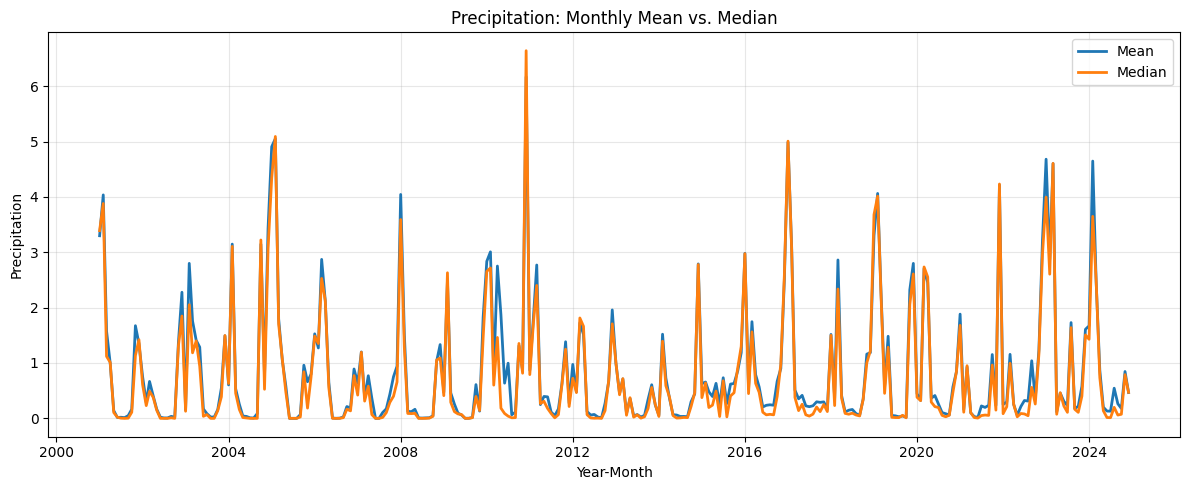

Precipitation Comparison:
              mean      median  difference
count  288.000000  288.000000  288.000000
mean     0.862590    0.753357    0.109233
std      1.130862    1.101210    0.197129
min      0.000000    0.000000   -0.471190
25%      0.116675    0.055625    0.009304
50%      0.391219    0.253333    0.054832
75%      1.156662    1.008750    0.160990
max      6.168810    6.640000    1.686280 



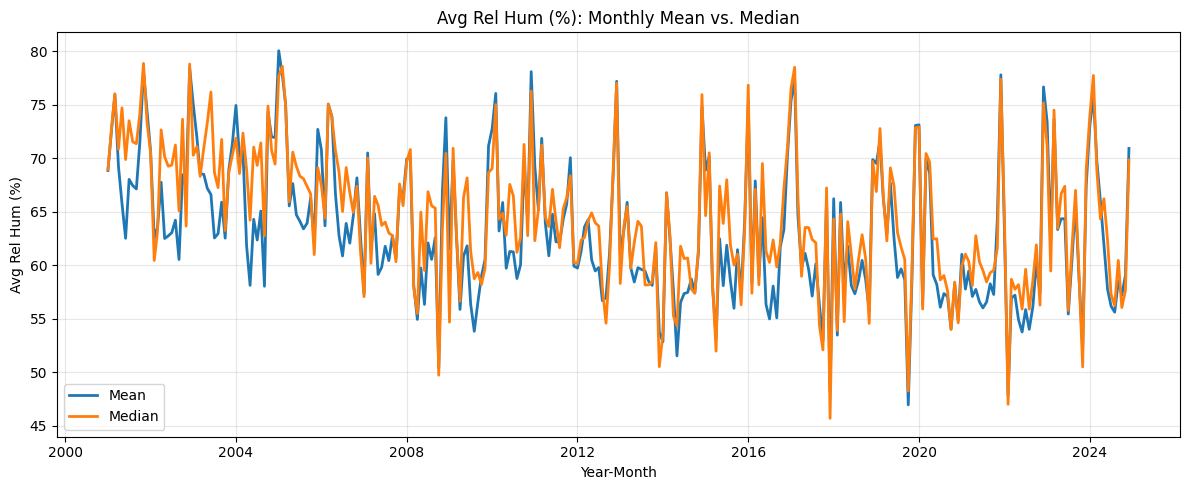

Avg Rel Hum (%) Comparison:
              mean      median  difference
count  288.000000  288.000000  288.000000
mean    63.223671   64.574897   -1.351226
std      6.426139    6.377589    2.771482
min     46.969453   45.708980   -9.575747
25%     58.310416   60.136970   -3.351061
50%     62.368247   64.149521   -0.834810
75%     67.511394   69.177818    0.487375
max     80.068841   78.881250    6.928995 



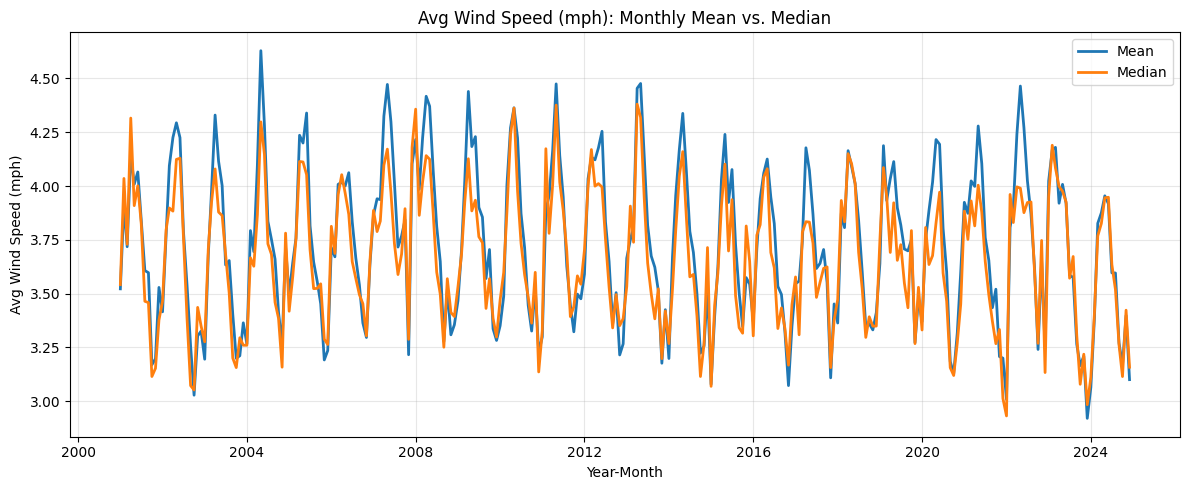

Avg Wind Speed (mph) Comparison:
              mean      median  difference
count  288.000000  288.000000  288.000000
mean     3.728183    3.659375    0.068808
std      0.361040    0.313825    0.124913
min      2.920651    2.931912   -0.284308
25%      3.443280    3.416835   -0.027220
50%      3.710896    3.660694    0.064365
75%      4.012499    3.907219    0.149605
max      4.628544    4.380326    0.474446 



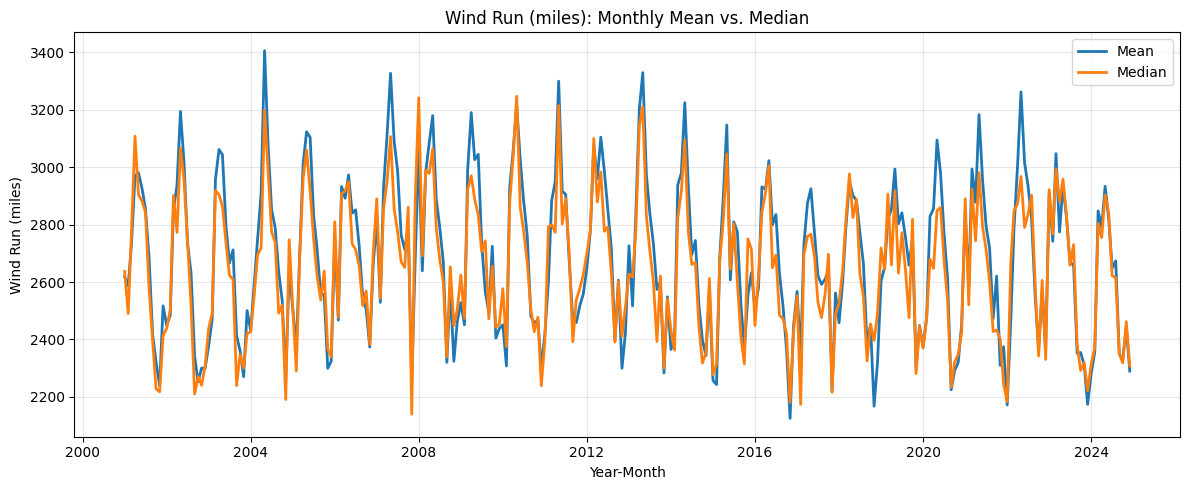

Wind Run (miles) Comparison:
               mean       median  difference
count   288.000000   288.000000  288.000000
mean   2682.287812  2645.445660   36.842152
std     270.459524   240.451651   90.897977
min    2125.237202  2139.933333 -229.103896
25%    2458.726838  2448.496875  -22.026796
50%    2670.808185  2650.491667   30.887876
75%    2890.079427  2825.454167   98.788467
max    3406.211875  3247.379167  294.962316 



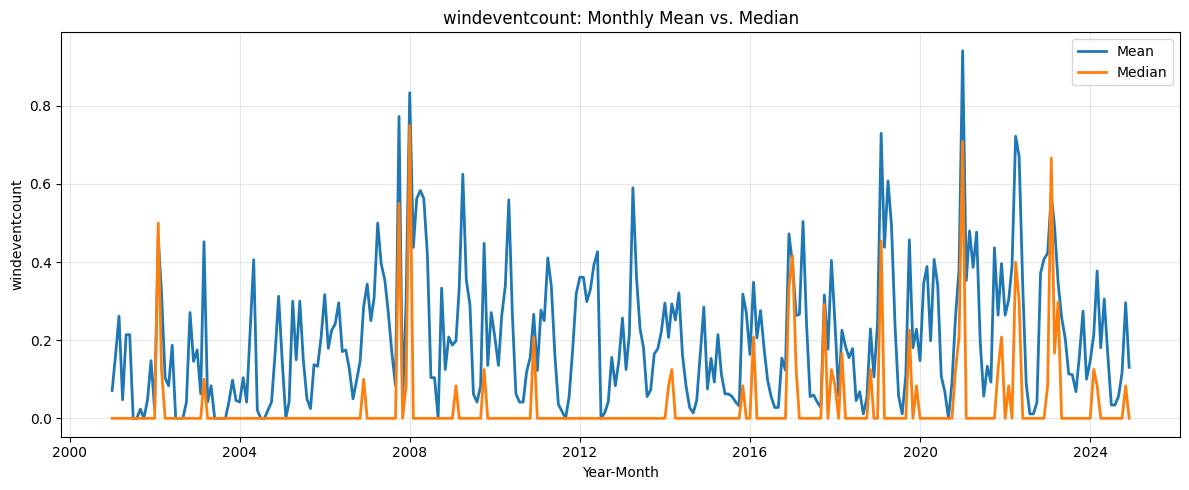

windeventcount Comparison:
              mean      median  difference
count  288.000000  288.000000  288.000000
mean     0.207534    0.032014    0.175520
std      0.169962    0.105451    0.140174
min      0.000000    0.000000   -0.094562
25%      0.062500    0.000000    0.056818
50%      0.175000    0.000000    0.150000
75%      0.304789    0.000000    0.264622
max      0.941153    0.750000    0.625000 



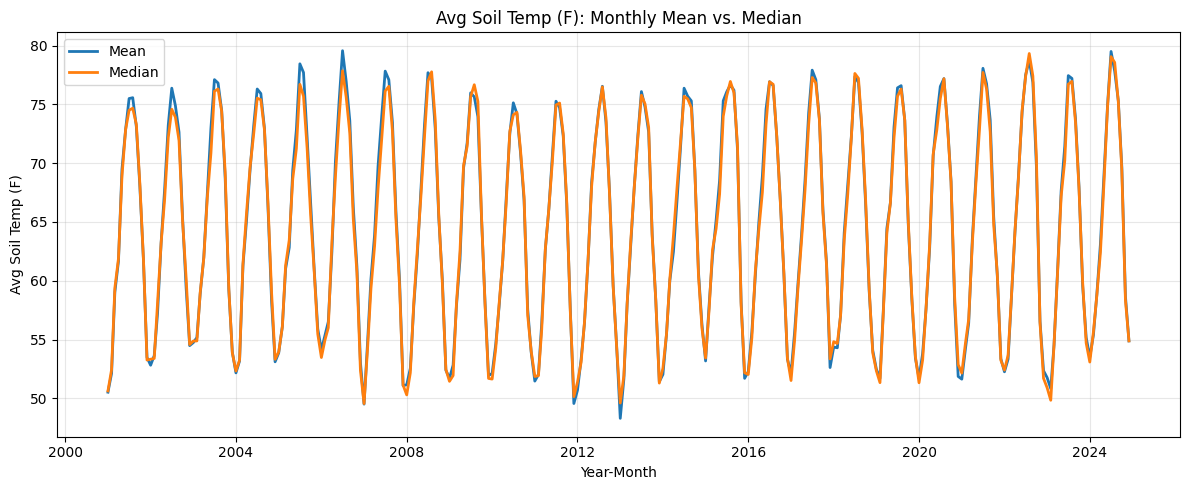

Avg Soil Temp (F) Comparison:
              mean      median  difference
count  288.000000  288.000000  288.000000
mean    64.640083   64.444682    0.195401
std      8.947217    8.782345    0.593896
min     48.300582   49.551965   -1.361189
25%     56.354470   55.994418   -0.186109
50%     65.077608   64.585766    0.128886
75%     73.232859   72.813221    0.515712
max     79.559883   79.322178    2.116808 



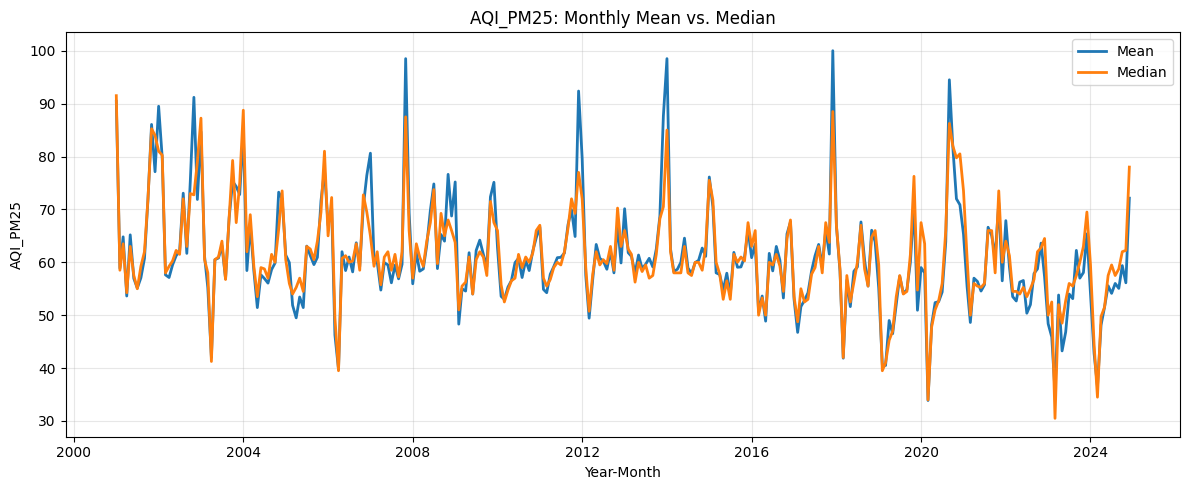

AQI_PM25 Comparison:
              mean      median  difference
count  288.000000  288.000000  288.000000
mean    61.019748   61.197917   -0.178168
std     10.083407    9.025799    3.662586
min     33.875000   30.500000   -9.625000
25%     55.546875   56.437500   -2.015625
50%     59.531250   60.000000   -0.468750
75%     64.578125   64.812500    0.890625
max    100.000000   91.500000   18.437500 



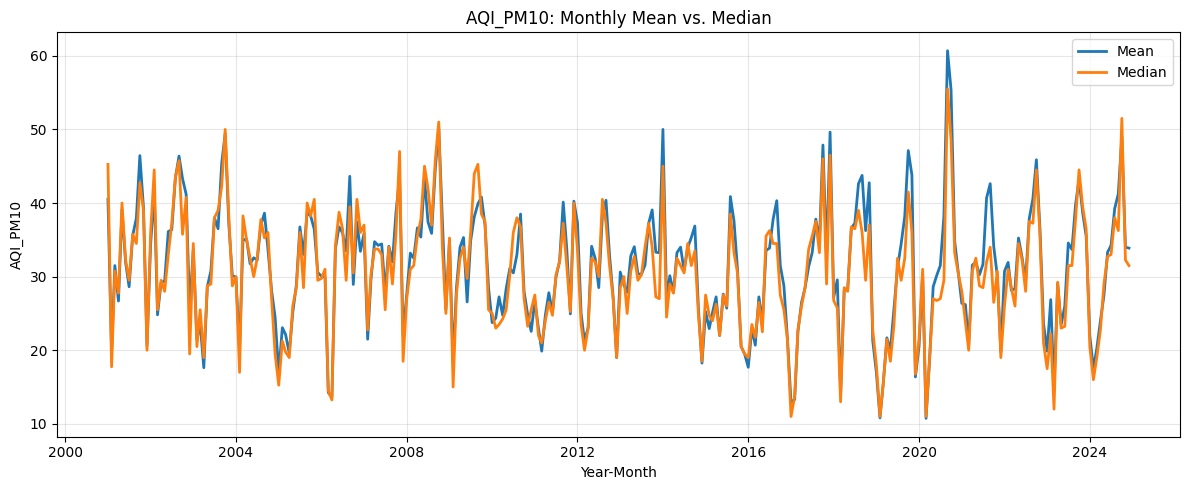

AQI_PM10 Comparison:
              mean      median  difference
count  288.000000  288.000000  288.000000
mean    31.280320   30.328125    0.952195
std      8.163066    8.046547    2.482522
min     10.750000   11.000000   -5.875000
25%     25.707589   25.187500   -0.500000
50%     31.531250   30.250000    0.656250
75%     36.625000   36.000000    2.375000
max     60.687500   55.500000    8.750000 



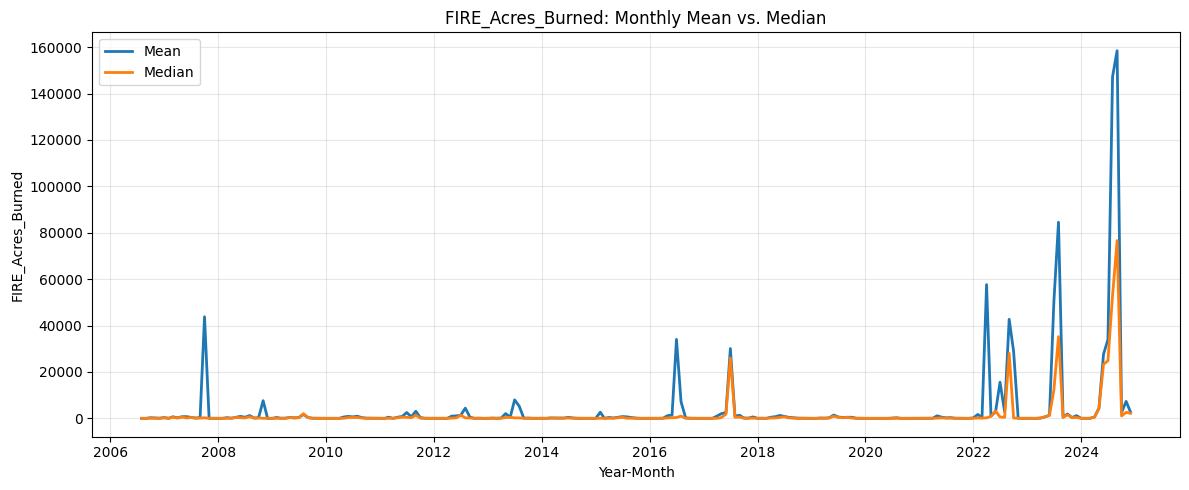

FIRE_Acres_Burned Comparison:
                 mean        median    difference
count     221.000000    221.000000    221.000000
mean     3977.993320   1481.180226   2496.813094
std     17258.487698   7465.388959  10892.655584
min         0.000000      0.000000   -366.175000
25%        16.562500      5.790000      2.288750
50%       139.596250     41.525000     43.375000
75%       716.198750    264.595000    326.952500
max    158478.000000  76615.500000  94341.875000 



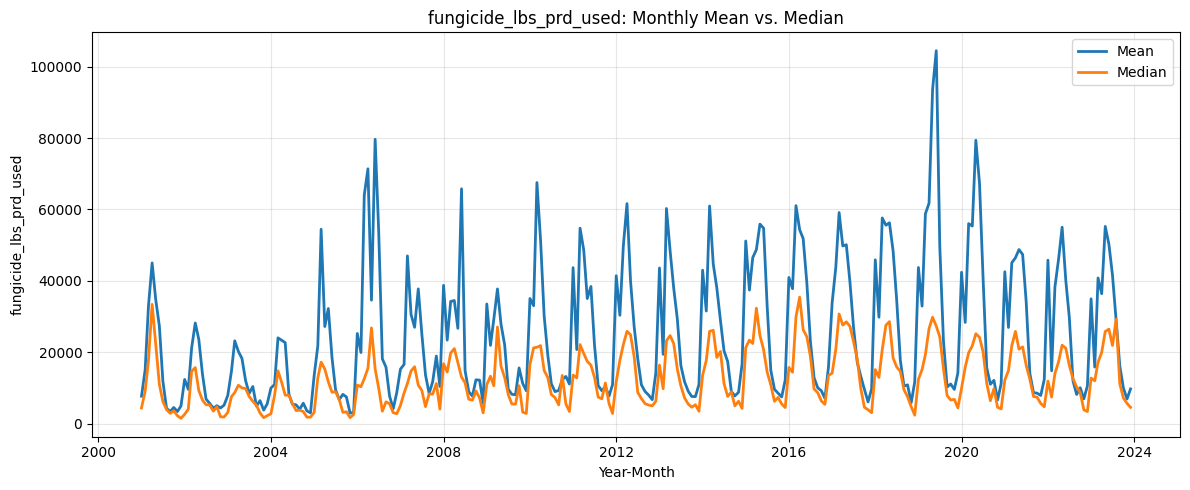

fungicide_lbs_prd_used Comparison:
                 mean        median    difference
count     276.000000    276.000000    276.000000
mean    25310.296685  12306.632773  13003.663913
std     19141.703790   7819.481370  13304.987073
min      2938.602437   1490.236650  -2122.285037
25%      9616.027216   5596.894100   3008.476084
50%     18237.342700  10776.236450   8467.658462
75%     38506.865544  17353.502150  19562.752037
max    104457.307225  35433.279750  77130.148175 



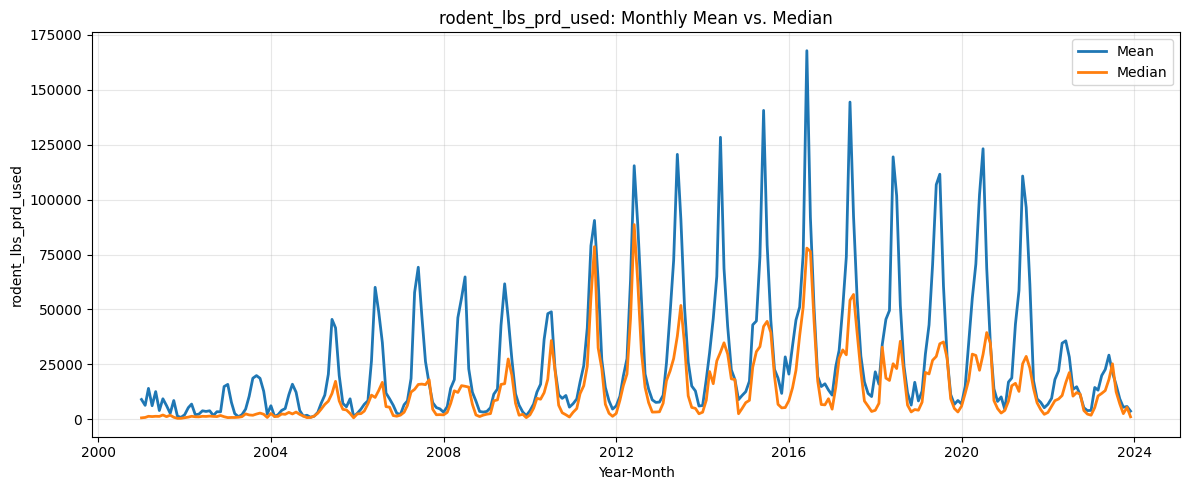

rodent_lbs_prd_used Comparison:
                 mean        median    difference
count     276.000000    276.000000    276.000000
mean    27292.558855  13275.790698  14016.768157
std     30564.424807  15031.931991  19813.338181
min       845.897563    409.306250  -3963.731762
25%      6810.842853   2499.427375   2666.247847
50%     14840.702331   7535.144250   6193.097081
75%     41592.044244  18277.904050  16831.752603
max    167826.990612  88643.999300  98376.191875 



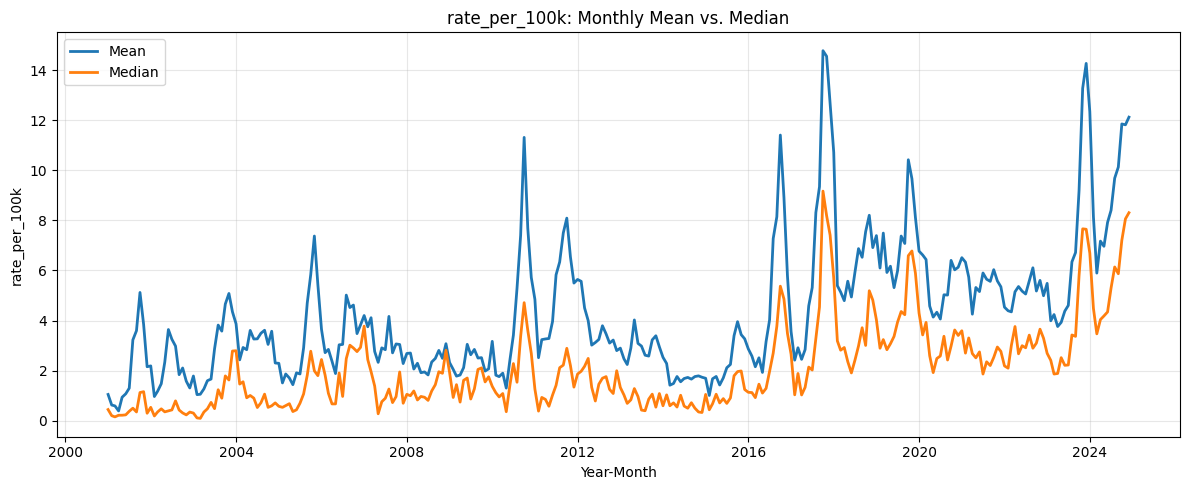

rate_per_100k Comparison:
              mean      median  difference
count  288.000000  288.000000  288.000000
mean     4.287749    2.075467    2.212282
std      2.686532    1.706075    1.273153
min      0.389830    0.094161    0.172281
25%      2.340743    0.831685    1.231548
50%      3.523955    1.700336    2.009464
75%      5.582575    2.848309    2.888732
max     14.772148    9.166043    6.622012 



In [ ]:
for var in variables:
    comparison = pd.DataFrame({
        "mean": monthly_mean[var],
        "median": monthly_median[var]
    })

    comparison["difference"] = comparison["mean"] - comparison["median"]

    plt.figure(figsize=(12,5))
    plt.plot(comparison.index, comparison["mean"], label="Mean", linewidth=2)
    plt.plot(comparison.index, comparison["median"], label="Median", linewidth=2)

    plt.title(f"{var}: Monthly Mean vs. Median")
    plt.xlabel("Year-Month")
    plt.ylabel(var)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'{var} Comparison:\n', comparison.describe(), '\n')

In [ ]:
# create the new ALL california monthly dataset

In [ ]:
monthly_all_df = (
    aggregate_all_counties_df
    .groupby("Year-Month", as_index=False)
    .agg({
        "Precipitation": "mean",
        "Avg Rel Hum (%)": "mean",
        "Avg Wind Speed (mph)": "mean",
        "Wind Run (miles)": "mean",
        "windeventcount": "mean",
        "Avg Soil Temp (F)": "mean",
        "AQI_PM25": "mean",
        "AQI_PM10": "mean",
        "FIRE_Acres_Burned": "median",
        "fungicide_lbs_prd_used": "median",
        "rodent_lbs_prd_used": "median",
        "rate_per_100k": "mean"
    })
)
monthly_all_df

,Year-Month,Precipitation,Avg Rel Hum (%),Avg Wind Speed (mph),Wind Run (miles),windeventcount,Avg Soil Temp (F),AQI_PM25,AQI_PM10,FIRE_Acres_Burned,fungicide_lbs_prd_used,rodent_lbs_prd_used,rate_per_100k
0,2001-01-01,3.297857,68.875000,3.522294,2618.515476,0.071429,50.526140,90.4375,40.5000,NaN,4395.45360,633.69475,1.047661
1,2001-02-01,4.035595,72.722462,3.916194,2586.921429,0.166667,52.125481,58.8750,19.6875,NaN,9071.70725,813.86195,0.625301
2,2001-03-01,1.575238,75.960526,3.718078,2731.164286,0.261905,59.033824,64.8125,31.5000,NaN,17723.88265,1338.29970,0.590922
3,2001-04-01,0.996429,69.248725,4.151603,2970.052381,0.047619,61.664271,53.6250,26.6875,NaN,33417.33930,1220.31340,0.389830
4,2001-05-01,0.140476,65.798855,4.007988,2980.953571,0.214286,69.491572,65.1875,39.1250,NaN,22334.85285,1341.28055,0.936698
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2024-08-01,0.544191,55.632990,3.595854,2674.035376,0.034091,77.821805,56.0000,39.2500,52890.0,NaN,NaN,9.684514
284,2024-09-01,0.263324,58.514057,3.270548,2349.681507,0.056818,75.303352,55.0625,41.2500,76615.5,NaN,NaN,10.127484
285,2024-10-01,0.179034,57.233556,3.168064,2328.647200,0.116883,69.680384,59.3750,49.0000,1021.0,NaN,NaN,11.848059
286,2024-11-01,0.845889,59.086648,3.398240,2445.109186,0.295996,58.672030,56.1250,34.0000,2574.5,NaN,NaN,11.813999


In [ ]:
monthly_all_df.to_csv("monthly_dataset.csv", index=False)

In [ ]:
corr_matrix = monthly_all_df.corr(numeric_only=True)
corr_matrix

,Precipitation,Avg Rel Hum (%),Avg Wind Speed (mph),Wind Run (miles),windeventcount,Avg Soil Temp (F),AQI_PM25,AQI_PM10,FIRE_Acres_Burned,fungicide_lbs_prd_used,rodent_lbs_prd_used,rate_per_100k
Precipitation,1.000000,0.671593,-0.087757,-0.153363,0.244198,-0.588509,-0.197642,-0.597827,-0.057347,-0.017245,-0.276090,-0.023895
Avg Rel Hum (%),0.671593,1.000000,-0.223849,-0.248113,-0.050837,-0.476051,-0.029813,-0.553527,-0.131323,-0.146731,-0.370965,-0.188675
Avg Wind Speed (mph),-0.087757,-0.223849,1.000000,0.942098,0.455979,0.200594,-0.502000,-0.289344,-0.085384,0.581113,0.307104,-0.376839
Wind Run (miles),-0.153363,-0.248113,0.942098,1.000000,0.404219,0.292436,-0.469638,-0.214715,-0.059819,0.561463,0.337433,-0.332718
windeventcount,0.244198,-0.050837,0.455979,0.404219,1.000000,-0.424771,-0.188177,-0.279373,-0.168555,0.305866,-0.102079,-0.022154
Avg Soil Temp (F),-0.588509,-0.476051,0.200594,0.292436,-0.424771,1.000000,-0.209091,0.454230,0.247999,0.090931,0.506366,0.002642
AQI_PM25,-0.197642,-0.029813,-0.502000,-0.469638,-0.188177,-0.209091,1.000000,0.542689,-0.081693,-0.477896,-0.234940,-0.034179
AQI_PM10,-0.597827,-0.553527,-0.289344,-0.214715,-0.279373,0.454230,0.542689,1.000000,0.141840,-0.324349,0.002245,0.182577
FIRE_Acres_Burned,-0.057347,-0.131323,-0.085384,-0.059819,-0.168555,0.247999,-0.081693,0.141840,1.000000,0.143041,0.101230,0.216615
fungicide_lbs_prd_used,-0.017245,-0.146731,0.581113,0.561463,0.305866,0.090931,-0.477896,-0.324349,0.143041,1.000000,0.456598,-0.159756


In [ ]:
monthly_all_df.describe()

,Year-Month,Precipitation,Avg Rel Hum (%),Avg Wind Speed (mph),Wind Run (miles),windeventcount,Avg Soil Temp (F),AQI_PM25,AQI_PM10,FIRE_Acres_Burned,fungicide_lbs_prd_used,rodent_lbs_prd_used,rate_per_100k
count,288,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,221.000000,276.000000,276.000000,288.000000
mean,2012-12-15 17:00:00,0.862590,63.223671,3.728183,2682.287812,0.207534,64.640083,61.019748,31.280320,1481.180226,12306.632773,13275.790698,4.287749
min,2001-01-01 00:00:00,0.000000,46.969453,2.920651,2125.237202,0.000000,48.300582,33.875000,10.750000,0.000000,1490.236650,409.306250,0.389830
25%,2006-12-24 06:00:00,0.116675,58.310416,3.443280,2458.726838,0.062500,56.354470,55.546875,25.707589,5.790000,5596.894100,2499.427375,2.340743
50%,2012-12-16 12:00:00,0.391219,62.368247,3.710896,2670.808185,0.175000,65.077608,59.531250,31.531250,41.525000,10776.236450,7535.144250,3.523955
75%,2018-12-08 18:00:00,1.156662,67.511394,4.012499,2890.079427,0.304789,73.232859,64.578125,36.625000,264.595000,17353.502150,18277.904050,5.582575
max,2024-12-01 00:00:00,6.168810,80.068841,4.628544,3406.211875,0.941153,79.559883,100.000000,60.687500,76615.500000,35433.279750,88643.999300,14.772148
std,NaN,1.130862,6.426139,0.361040,270.459524,0.169962,8.947217,10.083407,8.163066,7465.388959,7819.481370,15031.931991,2.686532


/tmp/ipykernel_14693/938259850.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


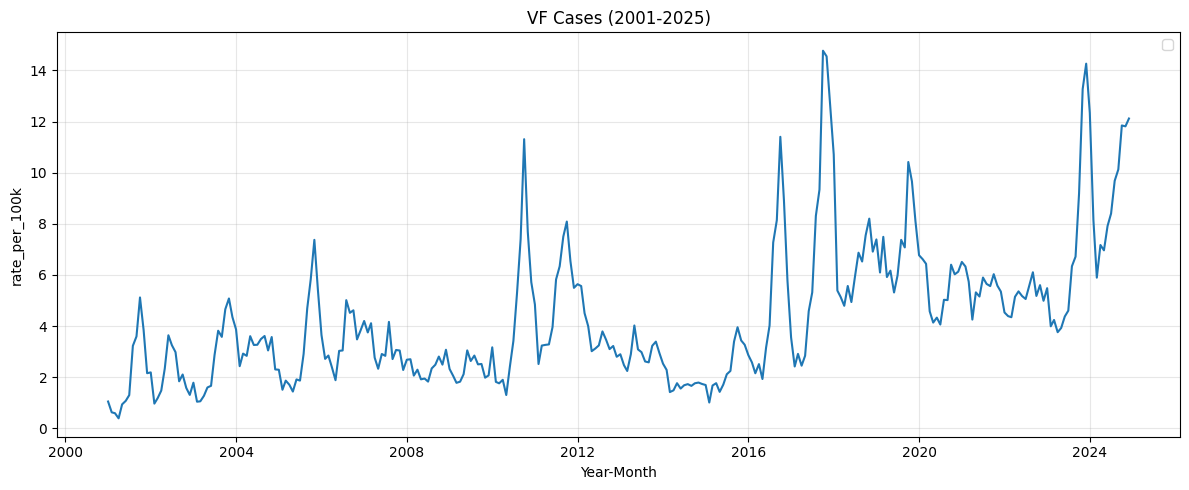

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(monthly_all_df["Year-Month"], monthly_all_df["rate_per_100k"])

plt.title(f"VF Cases (2001-2025)")
plt.xlabel("Year-Month")
plt.ylabel("rate_per_100k")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

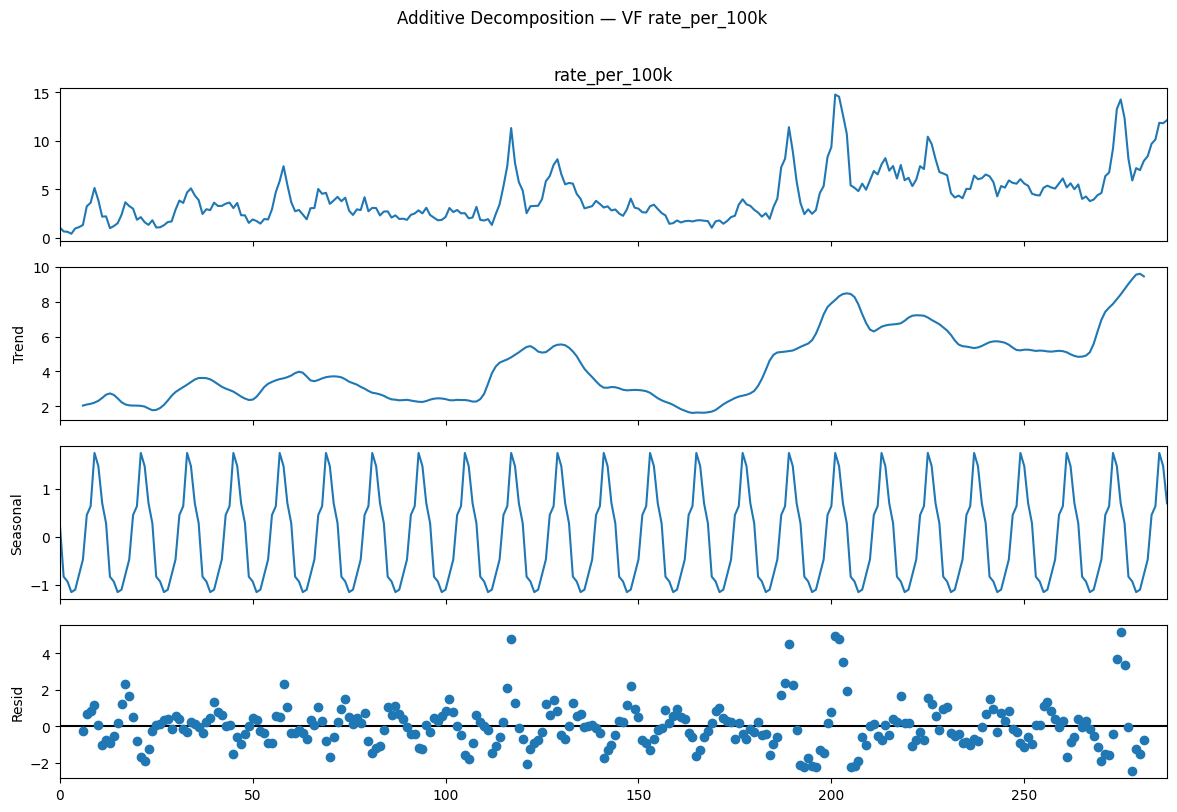

In [ ]:
# period=12 because we have monthly data with annual seasonality
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(monthly_all_df['rate_per_100k'], model='additive', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Additive Decomposition — VF rate_per_100k', y=1.01)
plt.tight_layout()
plt.show()

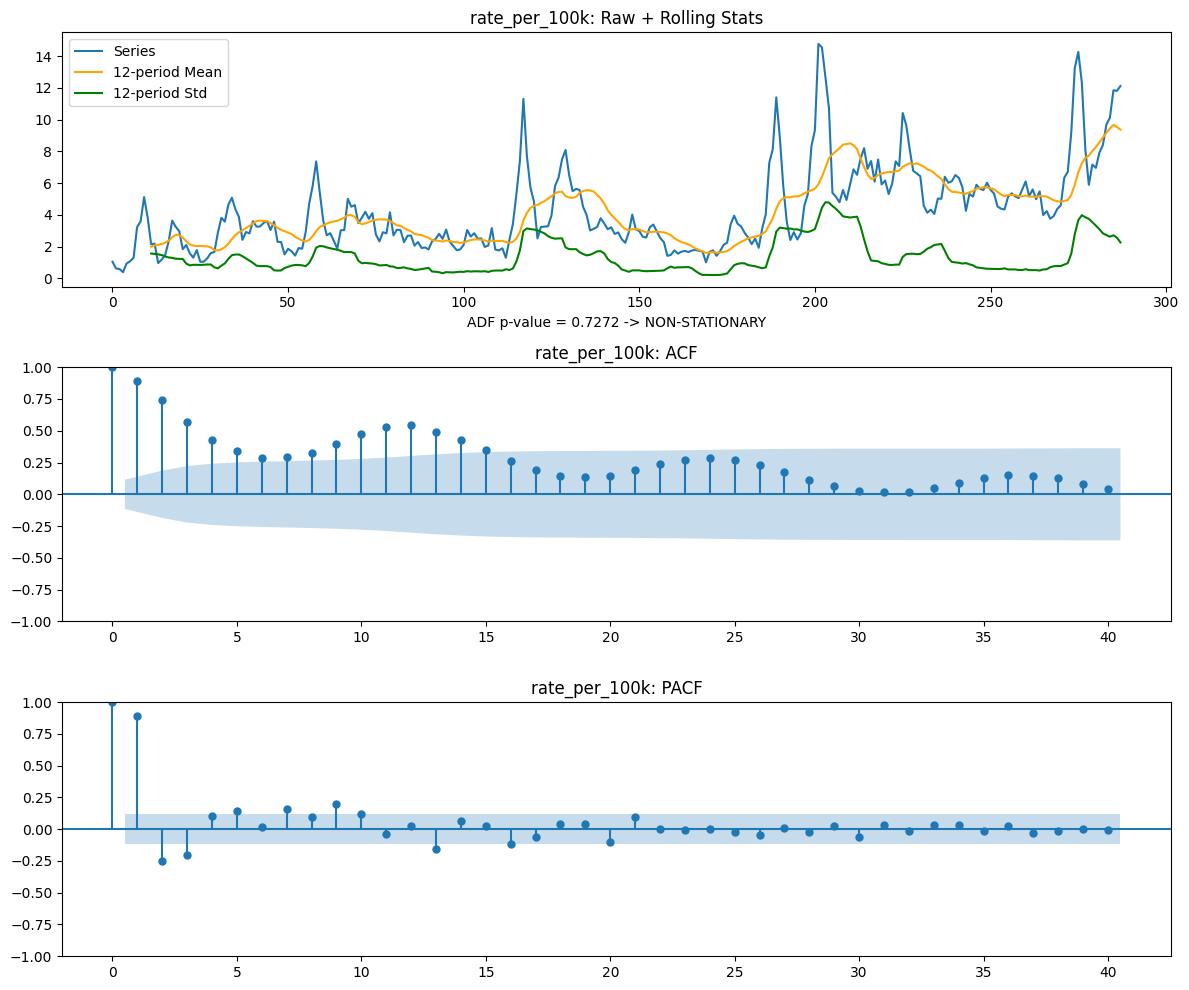

In [ ]:
utils.timeseries_diagnostics(monthly_all_df['rate_per_100k'], label='rate_per_100k', lags=40, rolling_window=12)

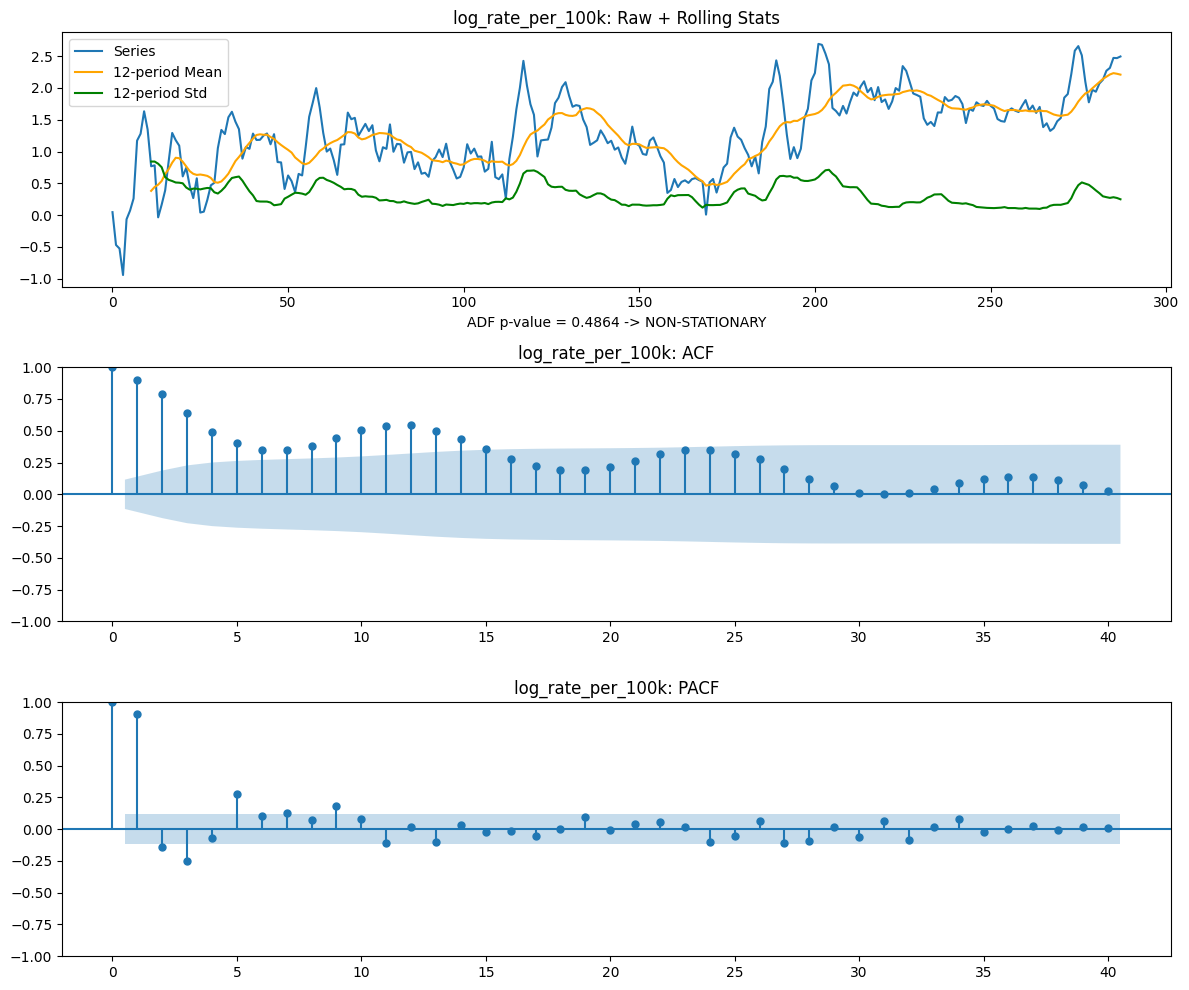

In [ ]:
# log transform of series
monthly_all_df['log_rate_per_100k'] = np.log(monthly_all_df['rate_per_100k'])
utils.timeseries_diagnostics(monthly_all_df['log_rate_per_100k'], label='log_rate_per_100k', lags=40, rolling_window=12)

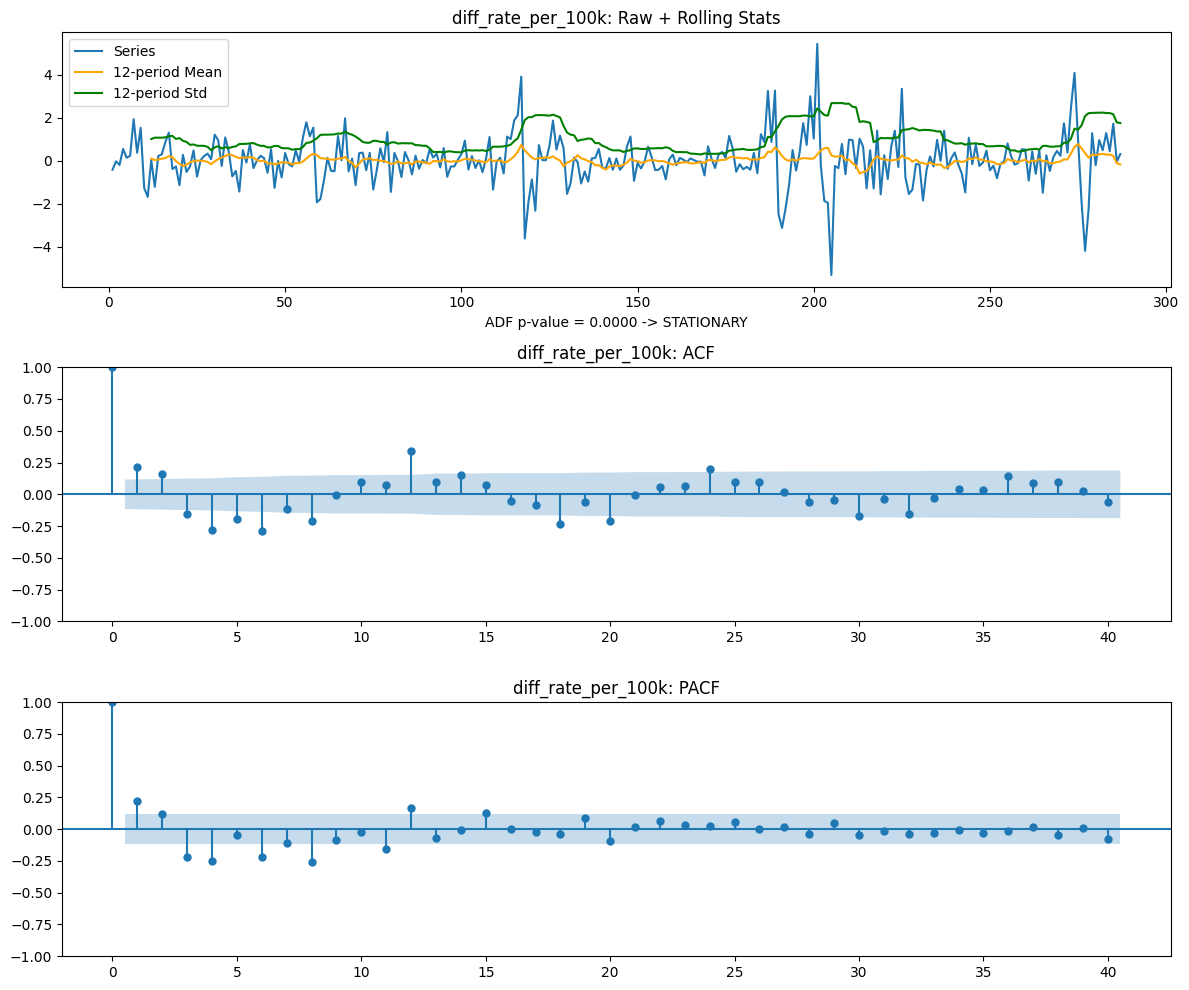

In [ ]:
# diff transform of series
monthly_all_df['diff_rate_per_100k'] = monthly_all_df['rate_per_100k'].diff()
utils.timeseries_diagnostics(monthly_all_df['diff_rate_per_100k'], label='diff_rate_per_100k', lags=40, rolling_window=12)
# using the diff transform, i found that lag=12 was the best

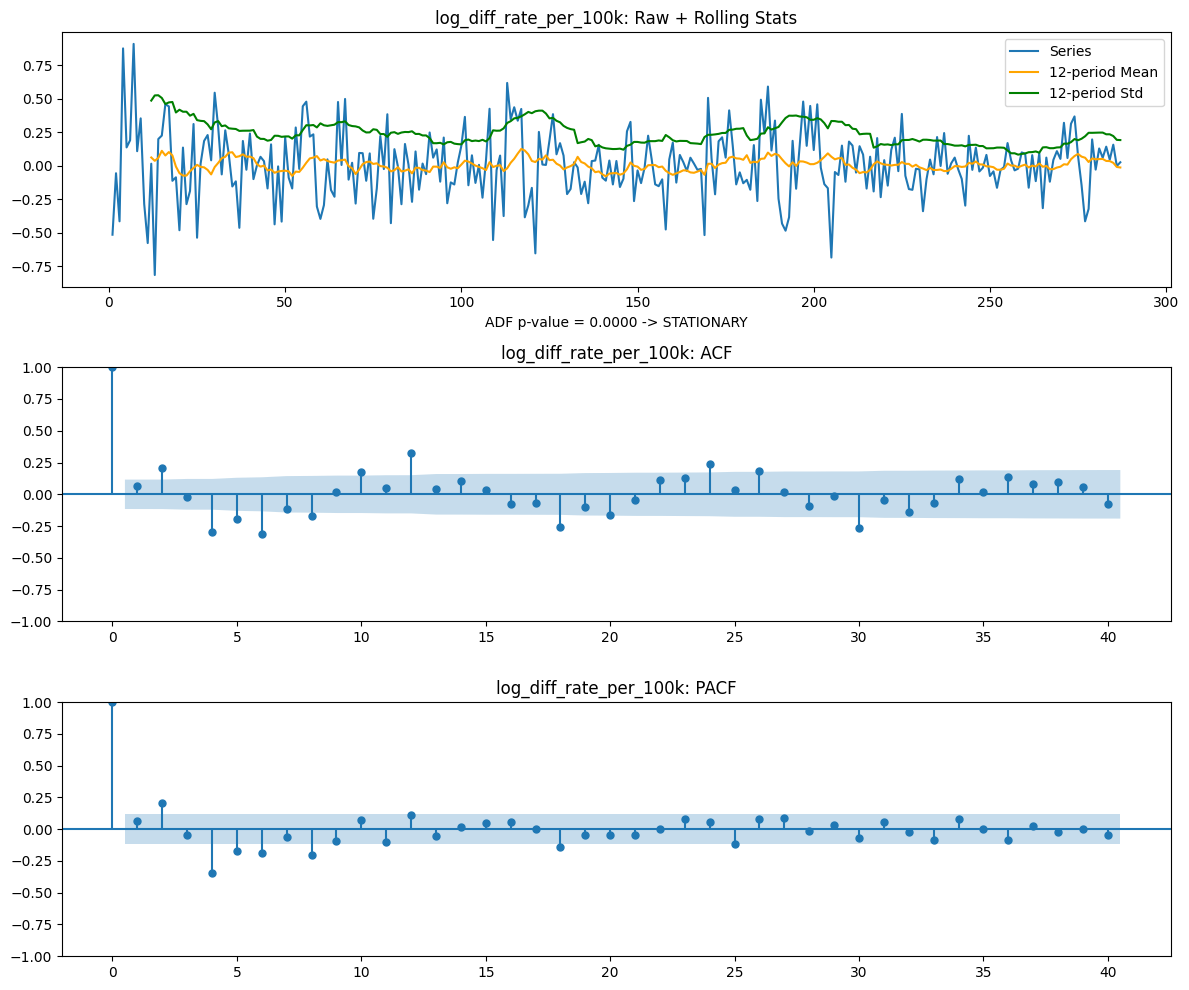

In [ ]:
# log diff transform of series
monthly_all_df['log_diff_rate_per_100k'] = np.log(monthly_all_df['rate_per_100k']).diff()
utils.timeseries_diagnostics(monthly_all_df['log_diff_rate_per_100k'], label='log_diff_rate_per_100k', lags=40, rolling_window=12)

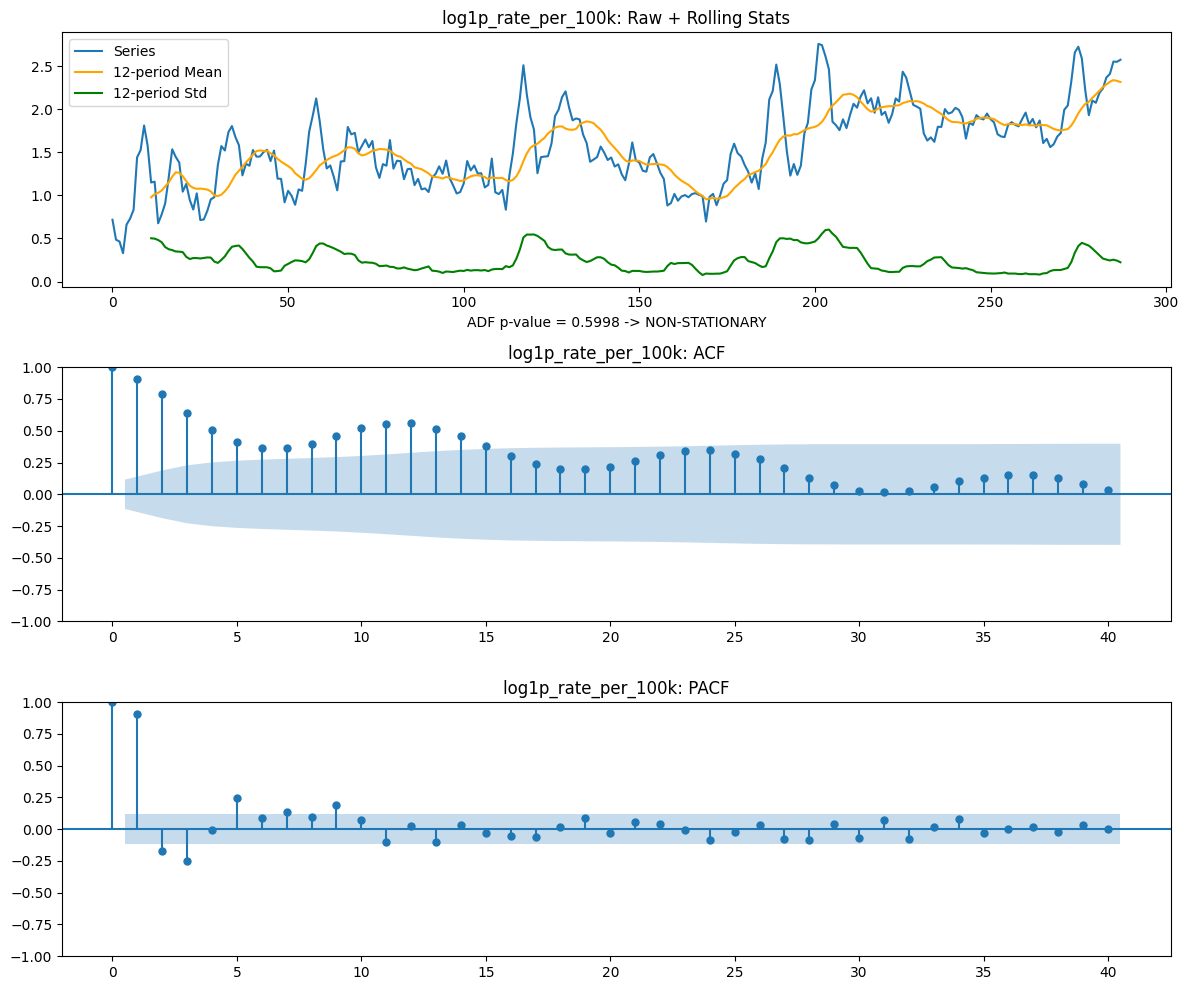

In [ ]:
# log1 transform of series
monthly_all_df['log1p_rate_per_100k'] = np.log1p(monthly_all_df['rate_per_100k'])
utils.timeseries_diagnostics(monthly_all_df['log1p_rate_per_100k'], label='log1p_rate_per_100k', lags=40, rolling_window=12)